In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
import time
from wave_cluster import *

%load_ext autoreload
%autoreload 2

# Data

In [194]:
# US County level infections, population, geography
infections = pd.read_csv("../data/county/infections.csv", index_col = 0)
population = pd.read_csv("../data/county/population.csv", index_col = 0)
geography = pd.read_csv("../data/county/geography.csv", index_col = 0)

# US State level government response
gov_response = pd.read_csv("../data/state/gov_response.csv", index_col = 0)
gov_response = gov_response.loc[infections.index]

# Normalization of each locations time-series to be cases per 100,000 persons
norm = infections.apply(lambda x: x/(population.loc[x.name].iloc[0]))
infections = norm * 100000 # cases per 100,000

# Windowed average smoothing of each time-series 
# Using average of 7 days in front and behind burrent time-stamp, 
# and repeating 3 times for a smoother result. 
front = 7
back = 7
smoothed = window_average_2d(infections.to_numpy(), front = front, back = back)
smoothed = window_average_2d(smoothed, front = front, back = back)
smoothed = window_average_2d(smoothed, front = front, back = back)

# remove any negative entries (reporting errors still present after smoothing)
smoothed[smoothed < 0] = 0

# fix the indexes
smoothed_index = pd.to_datetime(infections.index[front*3:-back*3])
infections = pd.DataFrame(smoothed, index = smoothed_index, columns = infections.columns)
gov_response = gov_response.iloc[front*3:-back*3]
gov_response.index = pd.to_datetime(gov_response.index)

dataset = infections.to_numpy()

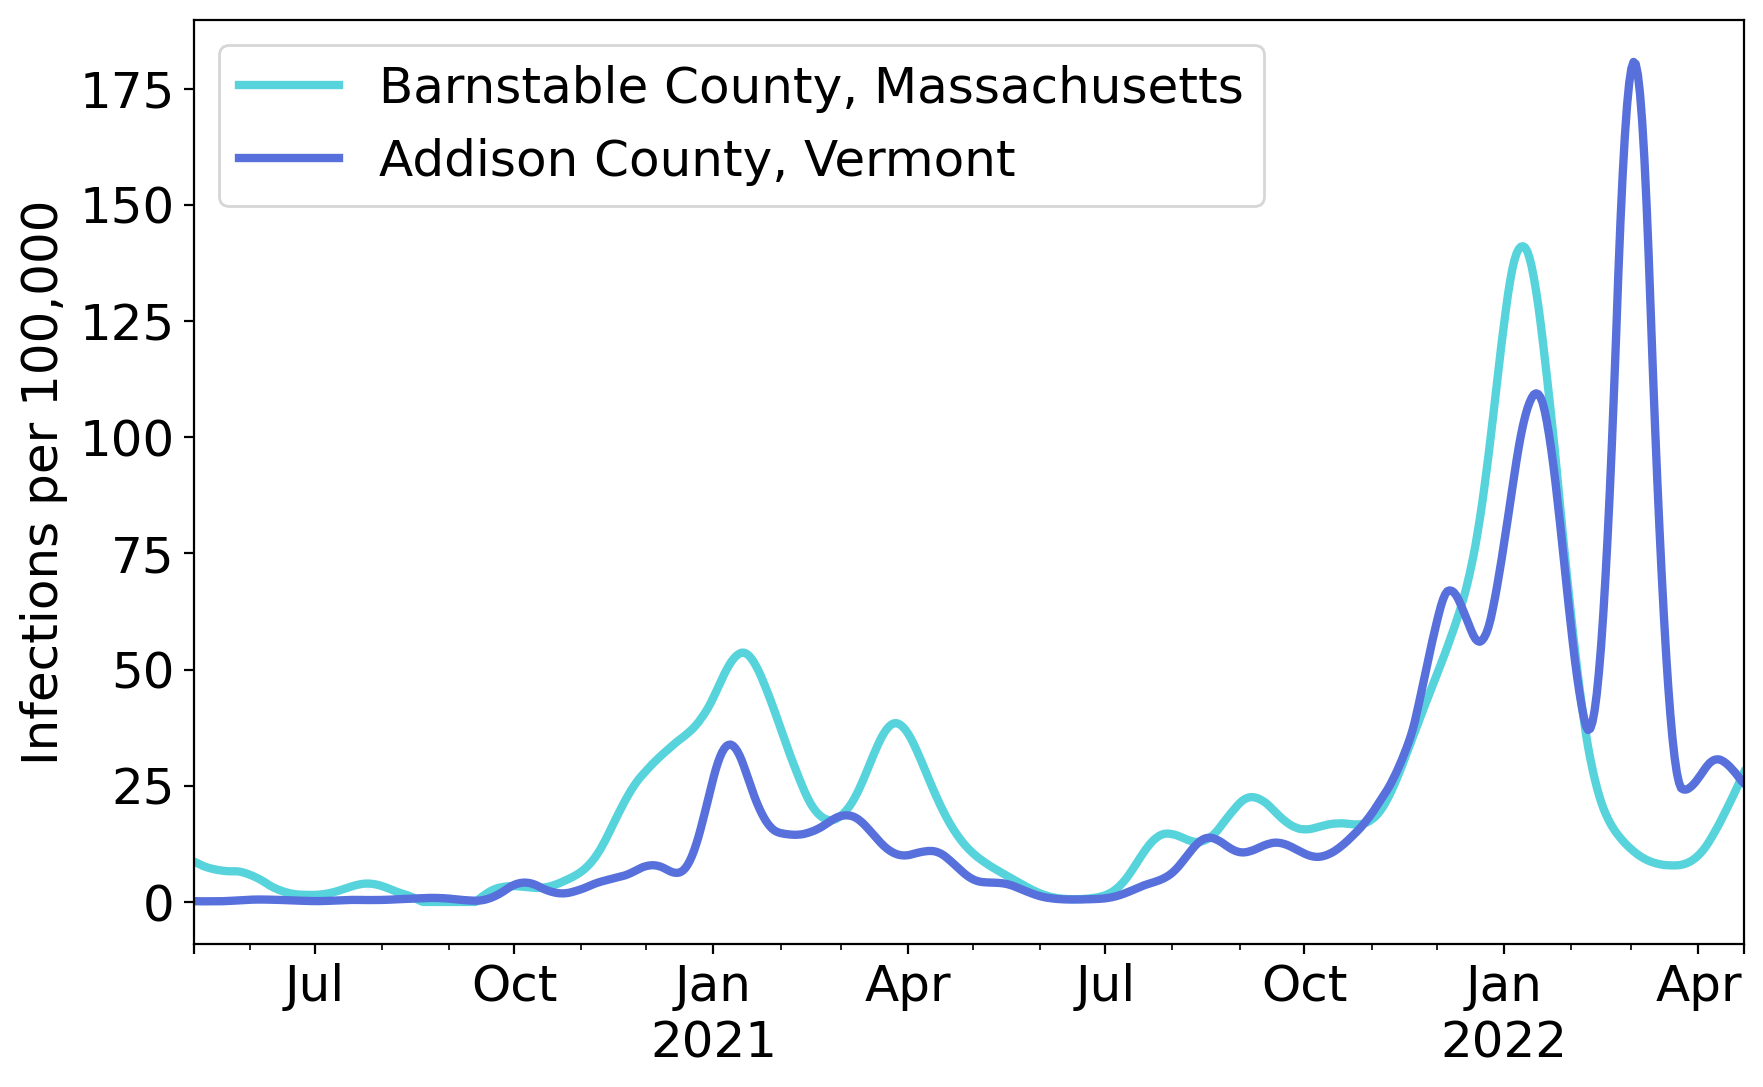

In [165]:
custom_palette = sns.color_palette("hls",8)[4:]
fix,ax = plt.subplots(dpi=200, figsize = (10,6))
plt.rcParams.update({'font.size':18})
sns.color_palette("hls", 8)
locations = ['US_MA_25001', 'US_VT_50001']
infections.loc[:,locations].plot(ax=ax, color = custom_palette, linewidth = 3)
#sns.lineplot(data, x = data.index, y = locations[0], palette = 'hls')
#sns.lineplot(data, x = data.index, y = locations[1], palette = 'hls')
ax.set_ylabel('Infections per 100,000')
ax.set_xlabel('')
plt.legend(['Barnstable County, Massachusetts', 'Addison County, Vermont'])

### Map visualization

In [199]:
# Shape file with geographic info for each state -- required for graphing
county_map = gpd.read_file("../data/county/visualization/tl_2021_us_county.shp")
drops = ['60', '66', '15', '02', '69', '72', '78'] 
county_map = county_map.drop(county_map.loc[county_map.STATEFP.isin(drops)].index, axis = 0)
county_map.index = range(len(county_map))

([], [])

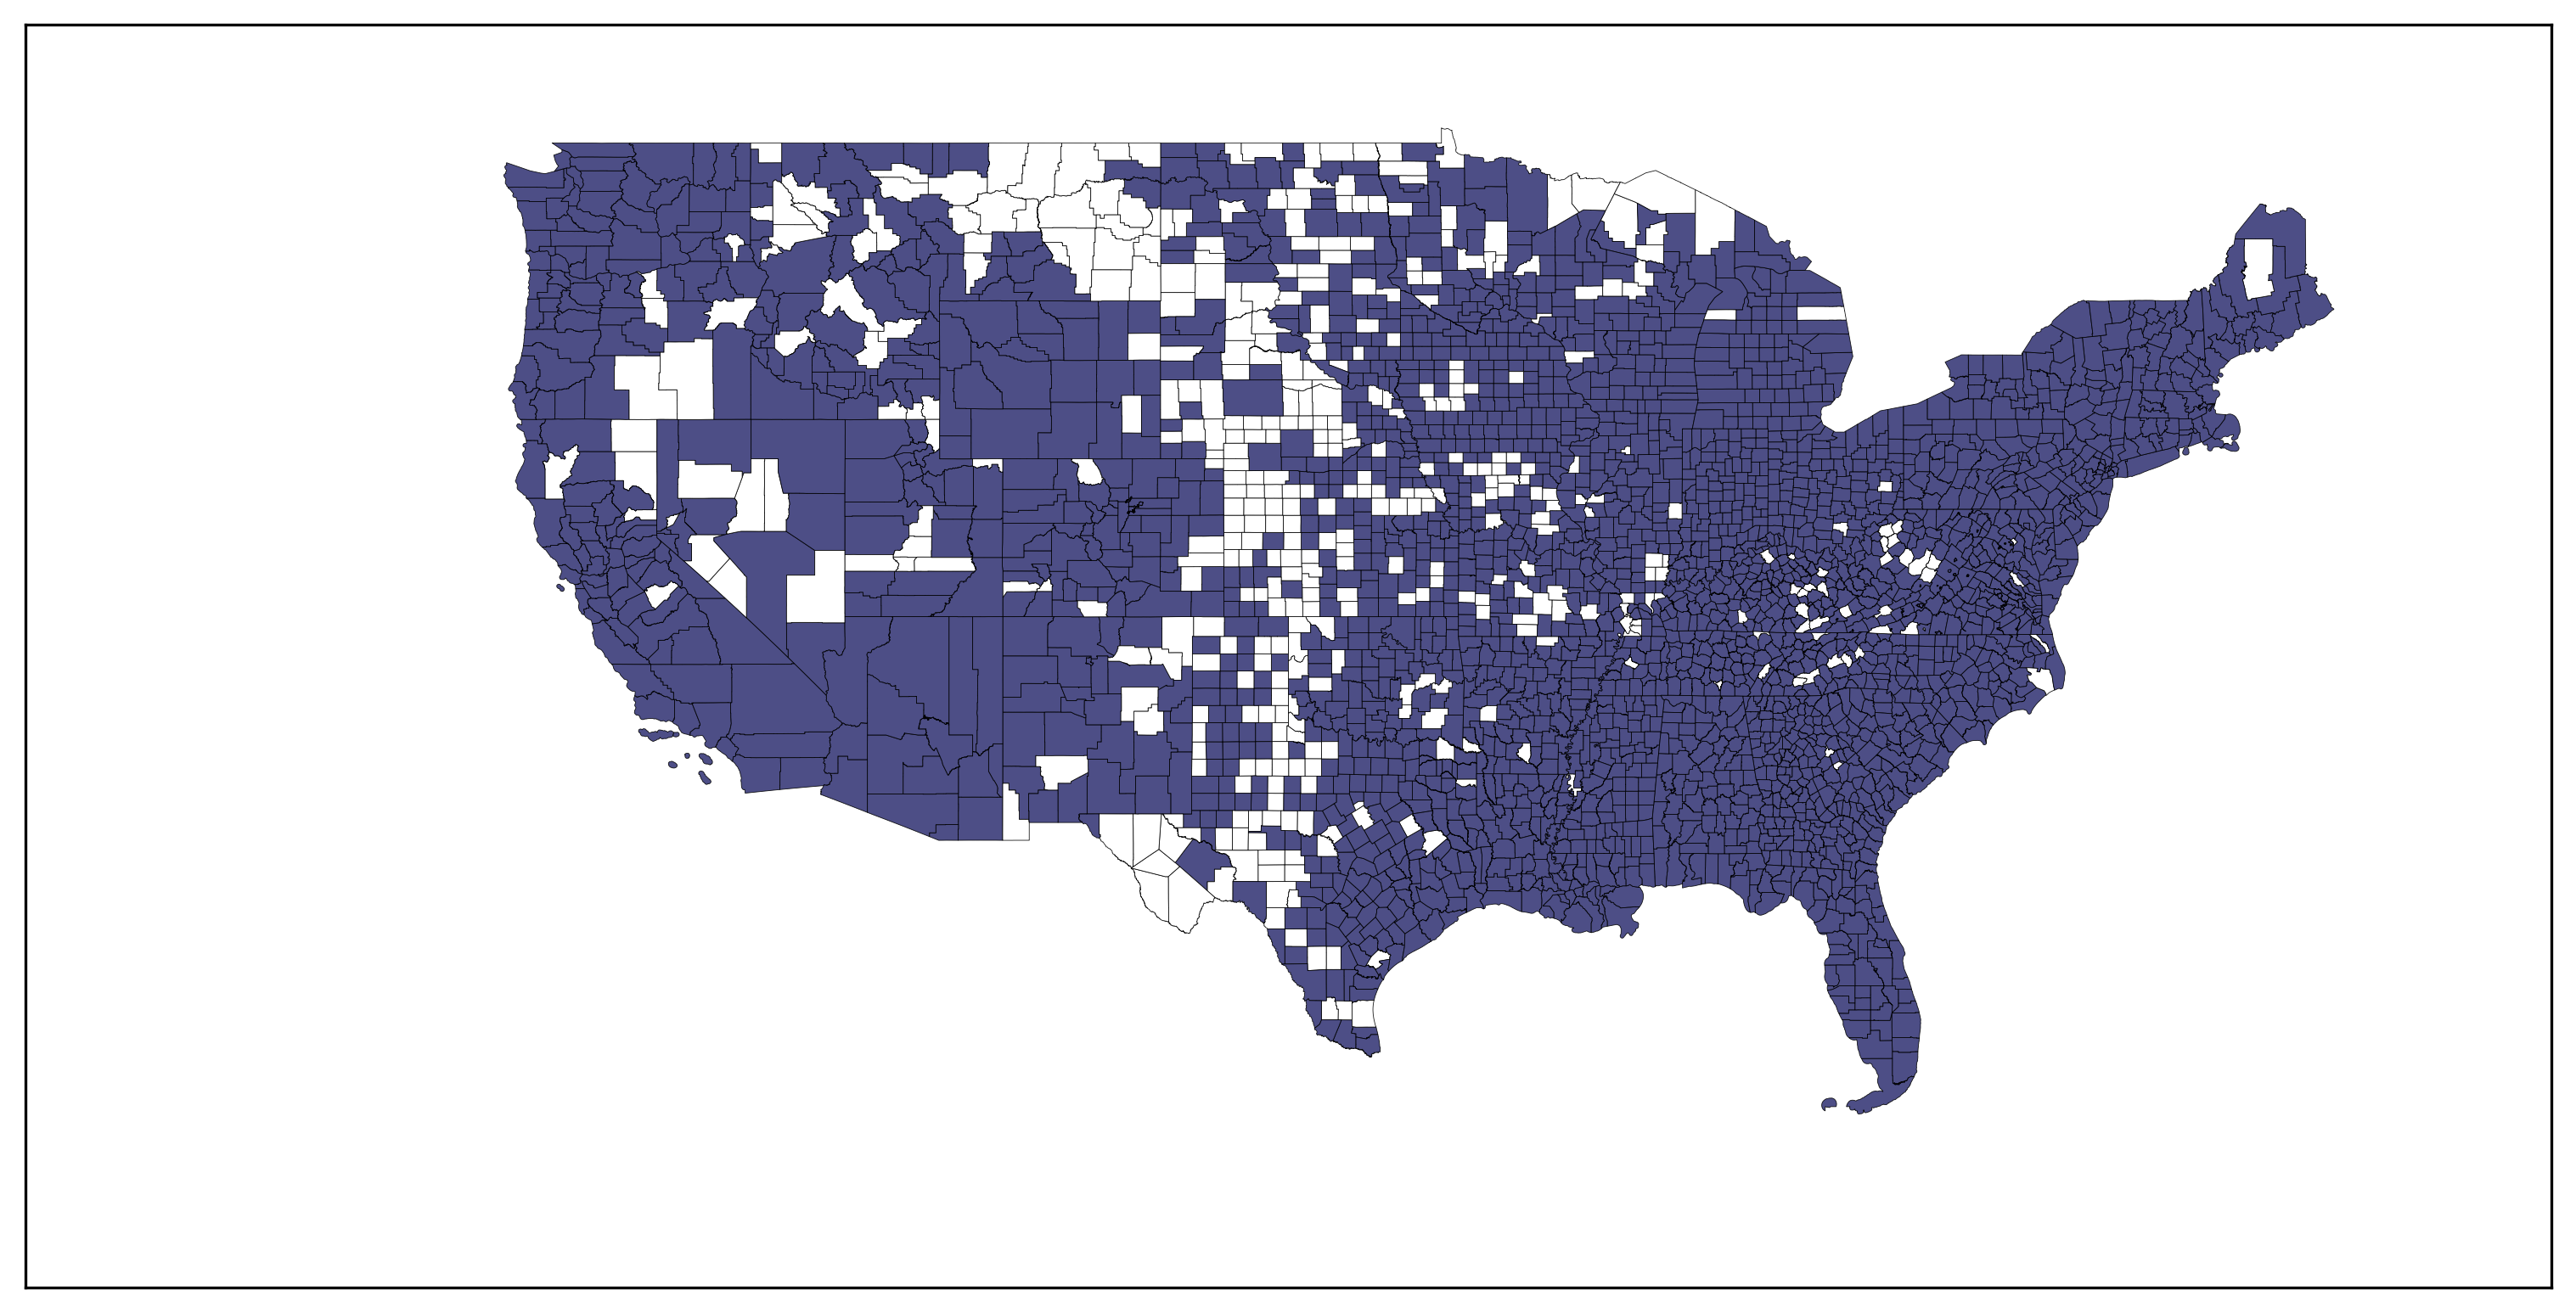

In [203]:
sequential_cmap = plt.cm.tab20b
colors = [(1, 1, 1)] + [sequential_cmap(i) for i in range(20)]
custom_cmap = ListedColormap(colors)
color_dict = {
    0 : custom_cmap(0), 1 : custom_cmap(1)
}

color_val = np.zeros(len(county_map))
for cname in infections.columns:
    state_code = cname[6:8]
    state_map = county_map.loc[county_map.STATEFP == state_code]
    region_code = cname[8:]
    idx = state_map.loc[state_map.COUNTYFP == region_code].index
    color_val[idx] = 1

color_val = [color_dict[_] for _ in color_val]
county_map['color'] = color_val

fig,ax = plt.subplots(1,1, constrained_layout=True, figsize = (10,10), dpi = 300)
county_map.plot(color=county_map['color'], legend=False, ax = ax, edgecolor = 'black', alpha = 0.9, linewidth = 0.2)
ax.set_xlim(-140, -60)
ax.set_ylim(20,52)
plt.xticks([])
plt.yticks([]) 